# 01 · Gaussian-Type Orbitals & Integral Computation

在量子化学中，基组（basis set）是我们表示分子轨道的"语言"。本 notebook 将从最底层的 GTO 出发，理解：

1. 什么是 primitive GTO 和 contracted GTO
2. 以 O 原子的 cc-pVDZ 为例，读懂 basis set 输出
3. libcint 积分库的核心数据结构：`atm`, `bas`, `env`
4. 用纯 PySCF 写一个 shell-by-shell 的积分计算程序

学完这个 notebook，你应该能看懂任何 basis set 文件的格式，并理解 `pyscf` 在 `mol.intor()` 调用背后做了什么。


---

## 1 · Gaussian-Type Orbitals

### 1.1 数学形式

一个 Cartesian Gaussian-Type Orbital (GTO) 的数学形式为：

$$
\chi(\mathbf{r}) = N \cdot (x - A_x)^{l_x} \, (y - A_y)^{l_y} \, (z - A_z)^{l_z} \, \exp\left(-\alpha |\mathbf{r} - \mathbf{A}|^2\right)
$$

其中：
- $\mathbf{A} = (A_x, A_y, A_z)$ 是轨道中心（通常是一个原子核位置）
- $l = l_x + l_y + l_z$ 是角动量量子数：$l=0$ 是 s 函数，$l=1$ 是 p 函数，$l=2$ 是 d 函数……
- $\alpha$ 是指数（exponent），控制函数的"宽度"
- $N$ 是归一化常数：$N = \left(\frac{2\alpha}{\pi}\right)^{3/4} \left(\frac{(8\alpha)^{l_x + l_y + l_z} \, l_x! \, l_y! \, l_z!}{(2l_x)! (2l_y)! (2l_z)!}\right)^{1/2}$

**为什么用 Gaussian？** 因为 Gaussian 函数的乘积仍然是 Gaussian，这使得双电子积分的解析计算成为可能——这是整个量子化学计算的基础。


### 1.2 STO vs GTO

量子力学告诉我们，类氢原子的精确径向波函数是 Slater 函数形式：

$$
\chi^{\text{STO}}(\mathbf{r}) = N \cdot r^{n-1} \, e^{-\zeta r} \, Y_{lm}(\theta, \phi)
$$

STO 在核附近有正确的 cusp（$r \to 0$ 时导数不连续），在远处指数衰减——物理上是对的。
但 STO 的乘积**不是** STO，导致双电子积分没有解析公式，只能靠数值积分，太慢了。

GTO 的乘积仍然是 GTO——这个性质让所有双电子积分可以用解析公式快速计算。**代价**是：单个 GTO 在 $r=0$ 处太平滑（没有 cusp），在远处衰减太快（$e^{-\alpha r^2}$ vs $e^{-\zeta r}$）。

**解决方案：收缩（contraction）**。将多个不同指数 $\alpha$ 的 primitive GTO 线性组合，拼出一个"长得像" STO 的 contracted GTO：

$$
\chi_{\mu}^{\text{CGTO}}(\mathbf{r}) = \sum_{p=1}^{K} d_{p\mu} \, \chi_p^{\text{PGTO}}(\mathbf{r}; \alpha_p)
$$

- 大的 $\alpha$（"紧"的 primitive）描述核附近的 cusp 行为
- 小的 $\alpha$（"diffuse"的 primitive）描述远处的指数衰减
- $d_{p\mu}$ 是收缩系数（contraction coefficient），通过最小二乘拟合 STO 得到

> **关键理解**：pgto 不是"没人用"——它是构建 cgto 的基本单元。我们实际计算中操作的是 cgto（一个 cgto = 一组 pgto 的固定线性组合）。基组的"大小"（nao）数的是 cgto 的个数，不是 pgto 的个数。


下面的例子展示了 **STO-3G**：用 3 个 primitive GTO 拟合一个 Slater 1s 轨道。


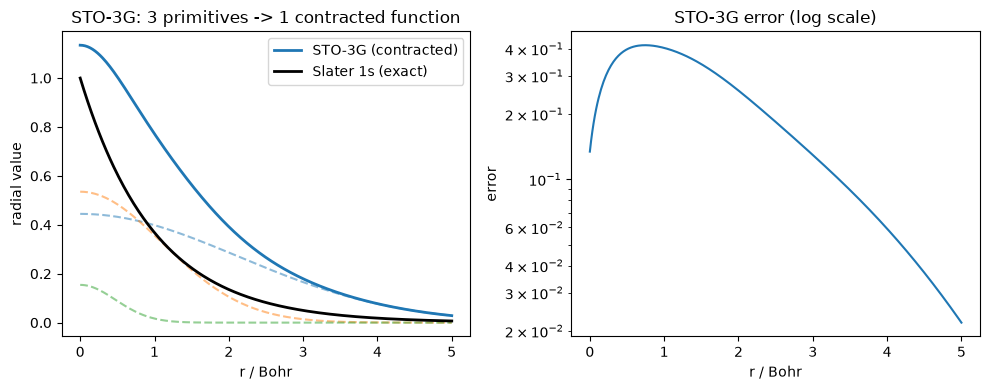

3 个 primitives 已经能较好地逼近 Slater 轨道


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 演示：用多个 primitive GTO 收缩来逼近类 1s 轨道

def contracted_gto(coeffs, alphas, z):
    '''计算 contracted GTO 沿 z 轴的值'''
    result = np.zeros_like(z)
    for c, a in zip(coeffs, alphas):
        result += c * np.exp(-a * z**2)
    return result

# 模拟 STO-3G: 用 3 个 Gaussian 逼近 Slater 1s (zeta=1.0)
# 这是 STO-3G 对 H 1s 的拟合参数
alphas_sto3g = [0.109818, 0.405771, 2.22766]
coeffs_sto3g = [0.444635, 0.535328, 0.154329]

z = np.linspace(0, 5, 300)
points = np.column_stack([np.zeros_like(z), np.zeros_like(z), z])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# 画出每个 primitive
for c, a in zip(coeffs_sto3g, alphas_sto3g):
    plt.plot(z, c * np.exp(-a * z**2), '--', alpha=0.5)
# 画出 contracted 结果和真正的 Slater 函数
contracted = contracted_gto(coeffs_sto3g, alphas_sto3g, z)
plt.plot(z, contracted, 'C0', linewidth=2, label='STO-3G (contracted)')
plt.plot(z, np.exp(-z), 'k-', linewidth=2, label='Slater 1s (exact)')
plt.xlabel('r / Bohr')
plt.ylabel('radial value')
plt.title('STO-3G: 3 primitives -> 1 contracted function')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(z, np.abs(contracted - np.exp(-z)))
plt.xlabel('r / Bohr')
plt.ylabel('error')
plt.title('STO-3G error (log scale)')
plt.yscale('log')

plt.tight_layout()
plt.show()
print("3 个 primitives 已经能较好地逼近 Slater 轨道")


### 1.3 读懂 Basis Set 输出: O cc-pVDZ

cc-pVDZ (correlation-consistent polarized valence double-zeta) 是 Dunning 提出的相关一致性基组。
用 PySCF 打印 O 原子的 cc-pVDZ 基组的完整输出如下：

```
BASIS "ao basis" SPHERICAL PRINT
#BASIS SET: (9s,4p,1d) -> [3s,2p,1d]
O    S
      1.172000E+04           7.100000E-04          -1.600000E-04           0.000000E+00
      1.759000E+03           5.470000E-03          -1.263000E-03           0.000000E+00
      4.008000E+02           2.783700E-02          -6.267000E-03           0.000000E+00
      1.137000E+02           1.048000E-01          -2.571600E-02           0.000000E+00
      3.703000E+01           2.830620E-01          -7.092400E-02           0.000000E+00
      1.327000E+01           4.487190E-01          -1.654110E-01           0.000000E+00
      5.025000E+00           2.709520E-01          -1.169550E-01           0.000000E+00
      1.013000E+00           1.545800E-02           5.573680E-01           0.000000E+00
      3.023000E-01          -2.585000E-03           5.727590E-01           1.000000E+00
O    P
      1.770000E+01           4.301800E-02           0.000000E+00
      3.854000E+00           2.289130E-01           0.000000E+00
      1.046000E+00           5.087280E-01           0.000000E+00
      2.753000E-01           4.605310E-01           1.000000E+00
O    D
      1.185000E+00           1.0000000
END
```

第一行的 `#BASIS SET: (9s,4p,1d) -> [3s,2p,1d]` 概括了整个基组的收缩方案：

| 符号 | 含义 |
|------|------|
| `(9s,4p,1d)` | 14 个 **primitive** GTOs: 9 个 s-type + 4 个 p-type + 1 个 d-type |
| `[3s,2p,1d]` | 6 个 **contracted** GTOs: 3 个 s-type + 2 个 p-type + 1 个 d-type |
| `SPHERICAL` | 使用球谐高斯函数（5 个 d 分量而非 6 个 Cartesian d） |
| `PRINT` | 打印基组的具体参数 |

下面逐段解读这些数据。


In [2]:
from pyscf import gto
import numpy as np
# 用 PySCF 生成 O 原子的 cc-pVDZ 基组并打印

mol_o = gto.M(
    atom='O 0 0 0',
    basis='cc-pVDZ',
    verbose=4,
)
mol_o.build()
print("=" * 60)
print("nao (number of AOs):", mol_o.nao)
print("nbas (number of shells):", mol_o.nbas)
print("=" * 60)


System: uname_result(system='Darwin', node='sunxinyudeMacBook-Air.local', release='25.5.0', version='Darwin Kernel Version 25.5.0: Mon Apr 27 20:38:00 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T8103', machine='arm64')  Threads 1
Python 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
numpy 2.5.0  scipy 1.18.0  h5py 3.16.0
Date: Fri Jul  3 22:38:57 2026
PySCF version 2.13.1
PySCF path  /Users/sunxinyu/develop/mini-tests/.venv/lib/python3.12/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 1
[INPUT] num. electrons = 8
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 O      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0

nuclear repulsio

number of shells = 5


number of NR pGTOs = 26


number of NR cGTOs = 14


basis = cc-pVDZ


ecp = {}


CPU time:         1.42


nao (number of AOs): 14
nbas (number of shells): 5


### 1.4 逐段解读

**S 壳层 (第 2-10 行)**：`O    S` 声明这是一个属于 O 原子的 s 型 shell。
接下来 9 行，每行是一个 primitive GTO，有 4 列数据：

| 列 | 含义 | 以第 1 个 primitive 为例 |
|----|------|------|
| 第 1 列 | 指数 $\alpha$ | `1.172E+04`（最"紧"的 primitive，描述核附近行为） |
| 第 2 列 | 第 1 个 s-type CGTO 的收缩系数 $d_{p,1}$ | `7.100E-04` |
| 第 3 列 | 第 2 个 s-type CGTO 的收缩系数 $d_{p,2}$ | `-1.600E-04` |
| 第 4 列 | 第 3 个 s-type CGTO 的收缩系数 $d_{p,3}$ | `0.000E+00` |

9 个 primitives、3 个 CGTOs。观察第 4 列（第 3 个 CGTO）：只有最后一个 primitive（$\alpha=0.3023$）的系数为 1.0，前 8 个均为 0。
这意味着**第 3 个 s-type CGTO 就是一个未经收缩的 primitive**——这就是 cc-pVDZ 的"双 zeta"特征：最 diffuse 的 s 函数独立成一个 CGTO，用于描述化学键的尾部行为。

**P 壳层 (第 12-16 行)**：`O    P` —— 4 个 primitives，2 个系数列（= 2 个 p-type CGTOs）。
前 3 个 primitives 收缩成第 1 个 CGTO，第 4 个 primitive（$\alpha=0.2753$）独立成为第 2 个 CGTO。

**D 壳层 (第 18 行)**：`O    D` —— 1 个 primitive，1 个系数（= 1 个 d-type CGTO）。
这是极化函数（polarization function），不做收缩，直接作为一个 CGTO。


In [3]:
# 查看 O cc-pVDZ 每个 shell 的 primitive 数量和 contraction 数量

def print_shell_info(mol):
    '''打印每个 shell 的详细信息'''
    print(f"{'Shell':>6s} {'Atom':>4s} {'L':>3s} {'nprim':>6s} {'ncontr':>6s}")
    print("-" * 35)
    for i in range(mol.nbas):
        atom_idx = mol.bas_atom(i)
        ang = mol.bas_angular(i)
        nprim = mol.bas_nprim(i)
        ncontr = mol.bas_nctr(i)
        atom_sym = mol.atom_symbol(atom_idx)
        ang_label = ['S', 'P', 'D', 'F', 'G', 'H'][ang]
        print(f"{i:>6d} {atom_sym:>4s} {ang_label:>3s} {nprim:>6d} {ncontr:>6d}")

print_shell_info(mol_o)


 Shell Atom   L  nprim ncontr
-----------------------------------
     0    O   S      8      2
     1    O   S      1      1
     2    O   P      3      1
     3    O   P      1      1
     4    O   D      1      1


### 1.5 H2O 分子的完整基组

现在用 H2O 分子来展示实际计算中的基组。H2O 用 cc-pVDZ，O 有 (9s,4p,1d)→[3s,2p,1d]，每个 H 有 (4s,1p)→[2s,1p]。

总共有多少个 AO？我们来数一数：


In [4]:
# 构建 H2O 分子

mol = gto.M(
    atom='''
        O   0.000000   0.000000   0.000000
        H   0.758602   0.000000   0.504284
        H   0.758602   0.000000  -0.504284
    ''',
    basis='cc-pVDZ',
    verbose=3,
)
mol.build()

print_shell_info(mol)
print(f"\nTotal shells: {mol.nbas}")
print(f"Total AOs:    {mol.nao}")

# 验证: 把每个 shell 的 CGTO 数量加起来
total_ao = sum(mol.bas_nctr(i) for i in range(mol.nbas))
print(f"Sum of nctr:  {total_ao}")


 Shell Atom   L  nprim ncontr
-----------------------------------
     0    O   S      8      2
     1    O   S      1      1
     2    O   P      3      1
     3    O   P      1      1
     4    O   D      1      1
     5    H   S      3      1
     6    H   S      1      1
     7    H   P      1      1
     8    H   S      3      1
     9    H   S      1      1
    10    H   P      1      1

Total shells: 11
Total AOs:    24
Sum of nctr:  12


---

## 2 · libcint 积分引擎

PySCF 的积分计算底层依赖 [libcint](https://github.com/sunqm/libcint)，
一个用 C 写的高效 Gaussian 积分库。它负责计算所有的高斯积分（重叠、动能、核吸引、ERI），
PySCF 通过 `mol.intor()` 调用它。

`mol` 对象内部把计算所需的信息编码为三个核心数组传给 libcint：

| 数组 | 含义 | 内容 |
|------|------|------|
| `mol._atm` | 原子信息 | 每个原子的核电荷数、坐标在 `env` 中的指针 |
| `mol._bas` | 基组信息 | 每个 shell 的角动量、primitive 数量、CGTO 数量、指数/系数在 `env` 中的指针 |
| `mol._env` | 具体数据 | 一维数组，存储所有浮点数：坐标、指数 $\alpha$、收缩系数 $d_{p\mu}$ |

理解这三个数组的结构，你就能直接读写任何 basis set 格式。下面我们用 H2O/cc-pVDZ 来看实际数据：


In [5]:
# 访问 PySCF 内部的 libcint 数据结构

atm = mol._atm
bas = mol._bas
env = mol._env

print("=" * 60)
print("atm 数组: 每个原子一行")
print("shape:", atm.shape)
print("列: [CHARGE, PTR_COORD, NUC_MOD, PTR_ZETA, PTR_FRAC, ...]")
print()
for i in range(mol.natm):
    charge = int(atm[i, 0])
    ptr_coord = int(atm[i, 1])
    x, y, z = env[ptr_coord: ptr_coord + 3]
    sym = mol.atom_symbol(i)
    print(f"  atm[{i}]: {sym} charge={charge}, coords=({x:.6f}, {y:.6f}, {z:.6f})")

print()
print("=" * 60)
print("bas 数组: 每个 shell 一行")
print("shape:", bas.shape)
print("列: [ATOM_ID, ANG, NPRIM, NCTR, PTR_EXP, PTR_COEFF, ...]")
print()
for i in range(mol.nbas):
    atom_id = int(bas[i, 0])
    ang = int(bas[i, 1])
    nprim = int(bas[i, 2])
    nctr = int(bas[i, 3])
    ptr_exp = int(bas[i, 5])
    ptr_coeff = int(bas[i, 6])
    sym = mol.atom_symbol(atom_id)
    ang_label = ['S', 'P', 'D', 'F', 'G', 'H'][ang]
    exponents = env[ptr_exp: ptr_exp + nprim]
    coeffs = env[ptr_coeff: ptr_coeff + nprim * nctr].reshape(nprim, nctr)
    print(f"  bas[{i}]: {sym} {ang_label}, nprim={nprim}, nctr={nctr}")
    print(f"          exponents: {np.array2string(exponents, precision=4, suppress_small=True)}")
    print(f"          coeffs[0] (first CGTO): {np.array2string(coeffs[:, 0], precision=6, suppress_small=True)}")

print()
print("=" * 60)
print("env 数组: 存储所有浮点数据（坐标, 指数, 收缩系数等）")
print("length:", len(env))


atm 数组: 每个原子一行
shape: (3, 6)
列: [CHARGE, PTR_COORD, NUC_MOD, PTR_ZETA, PTR_FRAC, ...]

  atm[0]: O charge=8, coords=(0.000000, 0.000000, 0.000000)
  atm[1]: H charge=1, coords=(1.433550, 0.000000, 0.952959)
  atm[2]: H charge=1, coords=(1.433550, 0.000000, -0.952959)

bas 数组: 每个 shell 一行
shape: (11, 8)
列: [ATOM_ID, ANG, NPRIM, NCTR, PTR_EXP, PTR_COEFF, ...]

  bas[0]: O S, nprim=8, nctr=2
          exponents: [11720.     1759.      400.8     113.7      37.03     13.27      5.025
     1.013]
          coeffs[0] (first CGTO): [ 2.01954   6.296752 10.72989   2.296375 -0.894856 -2.78736  -5.28623
 -1.948984]
  bas[1]: O S, nprim=1, nctr=1
          exponents: [0.3023]
          coeffs[0] (first CGTO): [1.030015]
  bas[2]: O P, nprim=3, nctr=1
          exponents: [17.7    3.854  1.046]
          coeffs[0] (first CGTO): [6.638565 5.254332 2.287482]
  bas[3]: O P, nprim=1, nctr=1
          exponents: [0.2753]
          coeffs[0] (first CGTO): [0.581758]
  bas[4]: O D, nprim=1, nctr=1
       

### 2.1 `mol.intor()` 的工作原理

`mol.intor("int1e_xxx_sph")` 调用 libcint，按 shell pair（而不是逐个 AO）计算积分。这利用了 Gaussian 积分的特性：**同一个 shell 中所有积分的中间量可以复用**，大大提高了效率。

`sph` 后缀表示球谐基函数。PySCF 内部用 Cartesian GTO 计算积分后再变换到球谐基，这个变换也是 libcint 完成的。

一个重要概念是 **`ao_loc`**（AO localization），它记录了每个 shell 对应哪些 AO 行/列：

```
ao_loc[i]   = 第 i 个 shell 之前的 AO 总数
ao_loc[i+1] = 第 i+1 个 shell 之前的 AO 总数
             = ao_loc[i] + shell_i 的 CGTO 数量
```

所以第 i 个 shell 的 AO 索引范围是 `[ao_loc[i], ao_loc[i+1])`。


In [6]:
# 演示 ao_loc 的含义

ao_loc = mol.ao_loc_nr()
print("Shell -> AO range:")
for i in range(mol.nbas):
    i0, i1 = ao_loc[i], ao_loc[i + 1]
    atom_sym = mol.atom_symbol(mol.bas_atom(i))
    ang = mol.bas_angular(i)
    ang_label = ['S', 'P', 'D', 'F', 'G', 'H'][ang]
    nctr = mol.bas_nctr(i)
    print(f"  shell {i:2d} ({atom_sym} {ang_label}): "
          f"AOs [{i0}:{i1}] (共 {nctr} 个 CGTO)")

print(f"\nnao = {mol.nao}, 最后一个 shell 的 i1 = {ao_loc[-1]}")


Shell -> AO range:
  shell  0 (O S): AOs [0:2] (共 2 个 CGTO)
  shell  1 (O S): AOs [2:3] (共 1 个 CGTO)
  shell  2 (O P): AOs [3:6] (共 1 个 CGTO)
  shell  3 (O P): AOs [6:9] (共 1 个 CGTO)
  shell  4 (O D): AOs [9:14] (共 1 个 CGTO)
  shell  5 (H S): AOs [14:15] (共 1 个 CGTO)
  shell  6 (H S): AOs [15:16] (共 1 个 CGTO)
  shell  7 (H P): AOs [16:19] (共 1 个 CGTO)
  shell  8 (H S): AOs [19:20] (共 1 个 CGTO)
  shell  9 (H S): AOs [20:21] (共 1 个 CGTO)
  shell 10 (H P): AOs [21:24] (共 1 个 CGTO)

nao = 24, 最后一个 shell 的 i1 = 24


---

## 3 · 手工计算分子积分

现在我们用 `mol.intor()` 和 shell 循环，从零写出 `_compute_all_integrals` 函数。这里没有黑魔法——每一行都是在调用 libcint 逐个 shell block 计算积分。

### 3.1 单电子积分

重叠积分 $S_{\mu\nu}$、动能积分 $T_{\mu\nu}$、核吸引积分 $V_{\mu\nu}$ 都是**单电子积分**，遍历 shell pairs 即可：


In [7]:
def compute_1e_integrals(mol):
    '''计算所有单电子积分: S, T, V, H = T + V'''
    nao = mol.nao
    nbas = mol.nbas
    ao_loc = mol.ao_loc_nr()

    S = np.zeros((nao, nao))
    T = np.zeros((nao, nao))
    V = np.zeros((nao, nao))

    for i in range(nbas):
        i0, i1 = ao_loc[i], ao_loc[i + 1]
        for j in range(i, nbas):
            j0, j1 = ao_loc[j], ao_loc[j + 1]

            # 一次调用计算整个 (i,j) shell block
            buf_s = mol.intor('int1e_ovlp_sph', shls_slice=(i, i + 1, j, j + 1))
            buf_t = mol.intor('int1e_kin_sph', shls_slice=(i, i + 1, j, j + 1))
            buf_v = mol.intor('int1e_nuc_sph', shls_slice=(i, i + 1, j, j + 1))

            # 填入矩阵 (利用对称性)
            S[i0:i1, j0:j1] = buf_s
            T[i0:i1, j0:j1] = buf_t
            V[i0:i1, j0:j1] = buf_v

            S[j0:j1, i0:i1] = buf_s.T
            T[j0:j1, i0:i1] = buf_t.T
            V[j0:j1, i0:i1] = buf_v.T

    H = T + V  # core Hamiltonian
    return S, T, V, H

S, T, V, H = compute_1e_integrals(mol)

# 与 PySCF 内置结果对比
S_ref = mol.intor('int1e_ovlp_sph')
assert np.allclose(S, S_ref), "S mismatch!"
print(f"S matrix: {mol.nao}x{mol.nao}, max|diff| = {np.max(np.abs(S - S_ref)):.2e}")

T_ref = mol.intor('int1e_kin_sph')
assert np.allclose(T, T_ref), "T mismatch!"
print(f"T matrix: {mol.nao}x{mol.nao}, max|diff| = {np.max(np.abs(T - T_ref)):.2e}")

V_ref = mol.intor('int1e_nuc_sph')
assert np.allclose(V, V_ref), "V mismatch!"
print(f"V matrix: {mol.nao}x{mol.nao}, max|diff| = {np.max(np.abs(V - V_ref)):.2e}")

print("All 1e integrals match PySCF built-in values.")


S matrix: 24x24, max|diff| = 1.67e-16
T matrix: 24x24, max|diff| = 9.99e-16
V matrix: 24x24, max|diff| = 3.55e-15
All 1e integrals match PySCF built-in values.


### 3.2 双电子积分 (ERI)

ERI (Electron Repulsion Integral) 是计算量最大的部分，形式为：

$$
(\mu\nu|\kappa\lambda) = \iint \chi_\mu(\mathbf{r}_1) \chi_\nu(\mathbf{r}_1) \, \frac{1}{r_{12}} \, \chi_\kappa(\mathbf{r}_2) \chi_\lambda(\mathbf{r}_2) \, d\mathbf{r}_1 d\mathbf{r}_2
$$

ERI 有 **8 重对称性**：

$$
(\mu\nu|\kappa\lambda) = (\nu\mu|\kappa\lambda) = (\mu\nu|\lambda\kappa) = (\nu\mu|\lambda\kappa)
= (\kappa\lambda|\mu\nu) = (\lambda\kappa|\mu\nu) = (\kappa\lambda|\nu\mu) = (\lambda\kappa|\nu\mu)
$$

利用这些对称性，我们只需计算约 1/8 的 shell quartets。在下面的代码中，通过对 `j`, `l` 循环施加约束（`j >= i`, `l >= k`），libcint 只返回唯一非冗余的 block，我们在填入 `eri` 数组时手动展开这 8 个排列。


In [8]:
def compute_eri(mol):
    '''计算 ERI 张量 (mu nu | kappa lambda) 并利用 8 重对称性'''
    nao = mol.nao
    nbas = mol.nbas
    ao_loc = mol.ao_loc_nr()

    eri = np.zeros((nao,) * 4)

    for i in range(nbas):
        i0, i1 = ao_loc[i], ao_loc[i + 1]
        for j in range(i, nbas):           # j >= i
            j0, j1 = ao_loc[j], ao_loc[j + 1]
            for k in range(nbas):
                k0, k1 = ao_loc[k], ao_loc[k + 1]
                for l in range(k, nbas):   # l >= k  -> 约 1/4 的 quartets
                    l0, l1 = ao_loc[l], ao_loc[l + 1]

                    # 一个 shell quartet 的全部积分
                    buf = mol.intor(
                        'int2e_sph',
                        shls_slice=(i, i + 1, j, j + 1, k, k + 1, l, l + 1),
                    )
                    # buf 的 shape: (ni, nj, nk, nl)
                    # 其中 ni = i1-i0, nj = j1-j0, nk = k1-k0, nl = l1-l0

                    # 8 重对称性展开
                    eri[i0:i1, j0:j1, k0:k1, l0:l1] = buf.transpose(0, 1, 2, 3)
                    eri[j0:j1, i0:i1, k0:k1, l0:l1] = buf.transpose(1, 0, 2, 3)
                    eri[i0:i1, j0:j1, l0:l1, k0:k1] = buf.transpose(0, 1, 3, 2)
                    eri[j0:j1, i0:i1, l0:l1, k0:k1] = buf.transpose(1, 0, 3, 2)
                    eri[k0:k1, l0:l1, i0:i1, j0:j1] = buf.transpose(2, 3, 0, 1)
                    eri[l0:l1, k0:k1, i0:i1, j0:j1] = buf.transpose(3, 2, 0, 1)
                    eri[k0:k1, l0:l1, j0:j1, i0:i1] = buf.transpose(2, 3, 1, 0)
                    eri[l0:l1, k0:k1, j0:j1, i0:i1] = buf.transpose(3, 2, 1, 0)

    return eri

print("Computing ERI for H2O/cc-pVDZ ...")
eri = compute_eri(mol)

# 验证: 与 PySCF 内置结果对比
eri_ref = mol.intor('int2e_sph')
assert np.allclose(eri, eri_ref), "ERI mismatch!"
print(f"ERI tensor: {mol.nao}x{mol.nao}x{mol.nao}x{mol.nao}")
print(f"Max |diff| = {np.max(np.abs(eri - eri_ref)):.2e}")
print(f"Number of elements: {eri.size:,}")
print(f"Non-zero elements:  {np.count_nonzero(eri > 1e-12):,}")
print(f"Sparsity:           {np.count_nonzero(eri > 1e-12) / eri.size * 100:.1f}%")
print("ERI matches PySCF built-in values.")


Computing ERI for H2O/cc-pVDZ ...


ERI tensor: 24x24x24x24
Max |diff| = 4.44e-16
Number of elements: 331,776
Non-zero elements:  89,484
Sparsity:           27.0%
ERI matches PySCF built-in values.


### 3.3 完整组装

把所有积分组装在一起，输出一个 `Integrals` 对象，方便后续 HF/MP2/CC 等模块使用：


In [9]:
class Integrals:
    '''分子积分容器: S, T, V, H, ERI'''
    def __init__(self, mol):
        self.mol = mol
        self.nao = mol.nao
        self.nbas = mol.nbas

    def compute_all(self):
        print("Computing 1e integrals...")
        self.S, self.T, self.V, self.H = compute_1e_integrals(self.mol)

        print("Computing 2e integrals (ERI)...")
        self.eri = compute_eri(self.mol)

        print("Done.")
        return self

    def summary(self):
        print(f"Molecule: {self.mol.atom_symbol(0)}")
        print(f"  nbas = {self.nbas}")
        print(f"  nao  = {self.nao}")
        print(f"  S:   {self.S.shape}, range [{self.S.min():.4f}, {self.S.max():.4f}]")
        print(f"  T:   {self.T.shape}, range [{self.T.min():.4f}, {self.T.max():.4f}]")
        print(f"  V:   {self.V.shape}, range [{self.V.min():.6f}, {self.V.max():.6f}]")
        print(f"  H:   {self.H.shape}, range [{self.H.min():.6f}, {self.H.max():.6f}]")
        nnz = np.count_nonzero(np.abs(self.eri) > 1e-14)
        print(f"  ERI: {self.eri.shape}, non-zero: {nnz:,} / {self.eri.size:,} ({100*nnz/self.eri.size:.1f}%)")

ints = Integrals(mol).compute_all()
ints.summary()


Computing 1e integrals...
Computing 2e integrals (ERI)...
Done.
Molecule: O
  nbas = 11
  nao  = 24
  S:   (24, 24), range [-0.4381, 1.0000]
  T:   (24, 24), range [-15.9497, 29.1866]
  V:   (24, 24), range [-62.269616, 23.830567]
  H:   (24, 24), range [-33.082975, 7.880911]
  ERI: (24, 24, 24, 24), non-zero: 157,148 / 331,776 (47.4%)


---

## 4 · 总结

本 notebook 涵盖了从基组到积分的完整底层流程：

| 层级 | 关键概念 |
|------|---------|
| **基组** | pgto (primitive GTO): 单个 Gaussian; cgto (contracted GTO): 多个 pgto 的线性组合 |
| **数据格式** | `(9s,4p,1d) -> [3s,2p,1d]` = 14 primitives 收缩为 6 contracted functions |
| **libcint** | `atm` (原子信息), `bas` (shell 定义), `env` (浮点数据) |
| **ao_loc** | shell -> AO 索引映射: shell i 对应 AOs `[ao_loc[i], ao_loc[i+1])` |
| **`mol.intor()`** | 按 shell block 调用 libcint，`sph` 后缀 = 球谐基 |
| **单电子积分** | S, T, V: 遍历 shell pairs (i <= j), 利用对称性 |
| **双电子积分** | ERI: 遍历 shell quartets (j >= i, l >= k), **8 重对称性**展开 |
| **验证** | 始终用 `mol.intor()` 的全量计算结果作为 reference |

你现在拥有了一套完整的分子积分计算代码——不需要任何外部量子化学包（只需要 PySCF 的 `intor` 做底层积分）。后续的 RHF、MP2、CCSD 等模块都将建立在 `Integrals` 类的基础上。
